## Задание

1. Исправить ошибки в реализации Transformer.
2. Придумать свою задачу seq2seq и обучить на ней модель.
3. Сравнить ожидаемые зачения и предсказания модели.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import copy

from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


` torch.device('cuda') `- просто возвращало объект, но не сохраняло в переменную

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [4]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

Исправление порядка операций.


БЫЛО: сначала feed_forward, потом attention
        
        ff_output = self.feed_forward(x)
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        x = self.norm2(x + self.dropout(ff_output))
        
  СТАЛО: сначала Self-Attention, потом Feed Forward

In [6]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

- Переменная `attn_output` не была определена, использовалась до присвоения

Изменение: сначала Self-Attention с маской декодера.

- Отсутствовал `Cross-Attention` с кодировщиком.

- Отсутствовала вторая нормализация перед `Feed Forward`

Изменение: `Feed Forward` с третьей нормализацией

In [7]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):

        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))

        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))

        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

- Неправильная размерность маски - `.unsqueeze(3) вместо .unsqueeze(2)`
Изменение: правильная размерность для маски декодера

In [8]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout, device):
        super(Transformer, self).__init__()
        self.device = device
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2).to(self.device)

        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(2).to(self.device)

        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length, device=self.device), diagonal=1)).bool()
        tgt_mask = tgt_mask & nopeak_mask

        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        output = self.fc(dec_output)
        return output

In [11]:
src_vocab_size = 1000
tgt_vocab_size = 2000
d_model = 512
num_heads = 8
num_layers = 6
d_ff = 2048
max_seq_length = 50
dropout = 0.1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Создаем экземпляр модели
transformer = Transformer(
    src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers,
    d_ff, max_seq_length, dropout, device
)
transformer = transformer.to(device)

Using device: cpu


In [12]:
from random import randint

In [14]:
def generate_sample():
    start = randint(1, 500)
    extra = 10

    src = torch.arange(start, start+max_seq_length+extra, dtype=torch.int64)
    trg = src + torch.arange(1, max_seq_length+extra+1, dtype=torch.int64)
    labels = trg[1:]

    return src[:max_seq_length], trg[:max_seq_length], labels[:max_seq_length]

In [15]:
def generate_batch(batch_size: int = 128):
    src_batch = torch.tensor([], dtype=torch.int64)
    trg_batch = torch.tensor([], dtype=torch.int64)
    labels_batch = torch.tensor([], dtype=torch.int64)

    while src_batch.shape[0] < batch_size:
        src_sample, trg_sample, labels_sample = generate_sample()
        src_batch = torch.cat((src_batch, src_sample.unsqueeze(0)))
        trg_batch = torch.cat((trg_batch, trg_sample.unsqueeze(0)))
        labels_batch = torch.cat((labels_batch, labels_sample.unsqueeze(0)))

    return src_batch, trg_batch, labels_batch


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

transformer.train()
train_loss_history = []

for step in tqdm(range(100)):
    src_batch, trg_batch, labels_batch = generate_batch(64)
    optimizer.zero_grad()
    output = transformer(src_batch.to(device), trg_batch.to(device))
    loss = criterion(output.view(-1, output.size(-1)), labels_batch.to(device).view(-1))
    loss.backward()
    optimizer.step()
    train_loss_history.append(loss.item())
    # print(f"Step: {step+1}, Loss: {loss.item()}")

100%|██████████| 100/100 [30:39<00:00, 18.39s/it]


## Visualize train loss

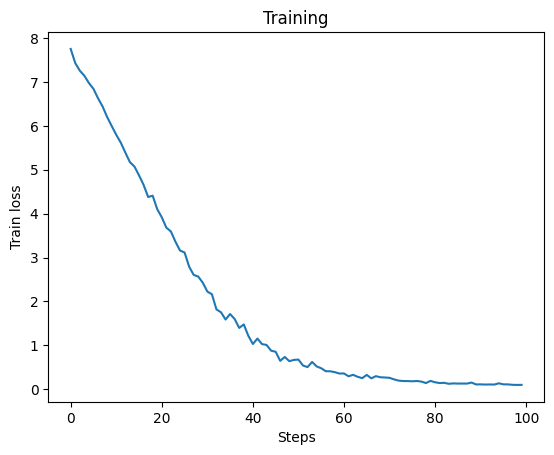

In [17]:
# Define X and Y variable data
x = np.array(list(range(len(train_loss_history))))
y = np.array(train_loss_history)

plt.plot(x, y)
plt.xlabel("Steps")  # add X-axis label
plt.ylabel("Train loss")  # add Y-axis label
plt.title("Training")  # add title
plt.show()

## Make batches for inference

In [18]:
transformer.eval()
src_batch, trg_batch, labels_batch = generate_batch(64)

In [19]:
preds_batch = torch.zeros_like(labels_batch)

In [20]:
# predict from first token
trg_batch[:,1:] = torch.full(trg_batch[:,1:].shape, 0)

## Inference

In [21]:
src_batch

tensor([[229, 230, 231,  ..., 276, 277, 278],
        [303, 304, 305,  ..., 350, 351, 352],
        [389, 390, 391,  ..., 436, 437, 438],
        ...,
        [323, 324, 325,  ..., 370, 371, 372],
        [466, 467, 468,  ..., 513, 514, 515],
        [144, 145, 146,  ..., 191, 192, 193]])

In [22]:
trg_batch

tensor([[230,   0,   0,  ...,   0,   0,   0],
        [304,   0,   0,  ...,   0,   0,   0],
        [390,   0,   0,  ...,   0,   0,   0],
        ...,
        [324,   0,   0,  ...,   0,   0,   0],
        [467,   0,   0,  ...,   0,   0,   0],
        [145,   0,   0,  ...,   0,   0,   0]])

In [23]:
preds_batch

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

In [24]:
# generating cycle
for i in range(trg_batch.shape[1]):
    res = transformer(src_batch.to(device), trg_batch.to(device))
    preds_batch[:,i] = res[:,i].argmax(dim=1)

    if i < trg_batch.shape[1]-1:
        trg_batch[:,i+1] = res[:,i].argmax(dim=1)

In [25]:
preds_batch

tensor([[232, 234, 236,  ..., 326, 328, 330],
        [306, 308, 310,  ..., 400, 402, 404],
        [392, 394, 396,  ..., 486, 488, 490],
        ...,
        [326, 328, 330,  ..., 420, 422, 424],
        [469, 471, 473,  ..., 563, 565, 567],
        [147, 149, 151,  ..., 241, 243, 245]])

In [26]:
labels_batch

tensor([[232, 234, 236,  ..., 326, 328, 330],
        [306, 308, 310,  ..., 400, 402, 404],
        [392, 394, 396,  ..., 486, 488, 490],
        ...,
        [326, 328, 330,  ..., 420, 422, 424],
        [469, 471, 473,  ..., 563, 565, 567],
        [147, 149, 151,  ..., 241, 243, 245]])

# **Задача: "Преобразование смайликов в текст эмоций"**

Описание: модель Transformer обучается переводить последовательности смайликов в текстовое описание эмоций на русском языке.

**Входная последовательность:** 1-4 смайлика подряд

**Выходная последовательность:** соответствующие эмоции через пробел


1. Распознавание каждого смайлика
2. Порядок эмоций (соответствует порядку смайликов)
3. Разделение эмоций пробелами в выходной последовательности
4. Композицию — обрабатывать последовательности разной длины

# Примеры работы модели

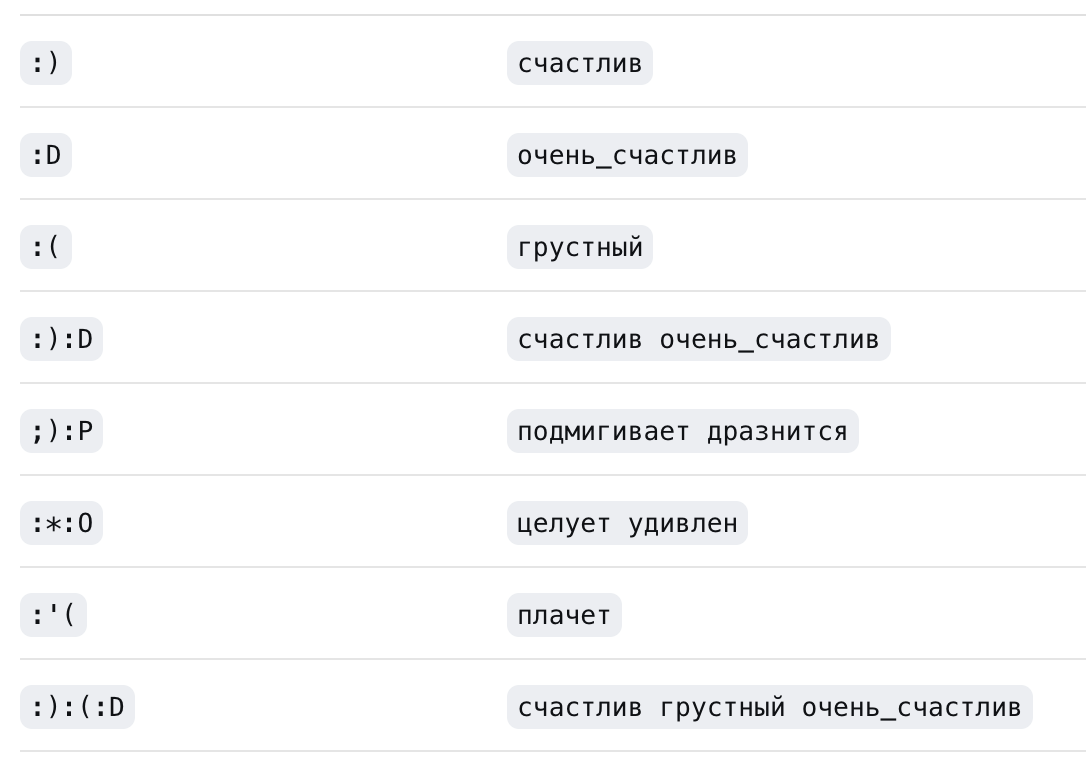

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

In [31]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        return torch.matmul(attn_probs, V)

    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, _, seq_length, _ = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        return self.W_o(self.combine_heads(attn_output))

class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()
        self.max_seq_length = max_seq_length
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        seq_len = min(x.size(1), self.max_seq_length)
        return x[:, :seq_len, :] + self.pe[:, :seq_len, :]

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout, device):
        super(Transformer, self).__init__()
        self.device = device
        self.max_seq_length = max_seq_length
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2).to(self.device)
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(2).to(self.device)
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool().to(self.device)
        tgt_mask = tgt_mask & nopeak_mask
        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        return self.fc(dec_output)

In [32]:
class EmojiToEmotionDataset:
    emoji_to_emotion = {
        ':)': 'счастлив',
        ':D': 'очень_счастлив',
        ';)': 'подмигивает',
        ':(': 'грустный',
        ':P': 'дразнится',
        ':*': 'целует',
        ':O': 'удивлен',
        ':|': 'нейтрален',
        ":'(": 'плачет',
        ':]': 'радостный'
    }

    def __init__(self, num_samples=30000, max_len=40):
        self.max_len = max_len
        self.chars = [':', ')', 'D', ';', '(', 'P', '*', 'O', '|', "'", ']', ' ', '_'] + \
                     list('абвгдежзийклмнопрстуфхцчшщъыьэюя')

        self.char_to_idx = {ch: i+3 for i, ch in enumerate(self.chars)}
        self.idx_to_char = {i+3: ch for i, ch in enumerate(self.chars)}
        self.char_to_idx['<PAD>'] = 0
        self.idx_to_char[0] = '<PAD>'
        self.char_to_idx['<SOS>'] = 1
        self.idx_to_char[1] = '<SOS>'
        self.char_to_idx['<EOS>'] = 2
        self.idx_to_char[2] = '<EOS>'
        self.vocab_size = len(self.chars) + 3

        self.pairs = []
        emoji_list = list(self.emoji_to_emotion.keys())

        for _ in range(num_samples):
            seq_length = random.randint(1, 4)
            emoji_seq = []
            emotion_seq = []
            for __ in range(seq_length):
                emoji = random.choice(emoji_list)
                emotion = self.emoji_to_emotion[emoji]
                emoji_seq.append(emoji)
                emotion_seq.append(emotion)
            input_text = ''.join(emoji_seq)
            output_text = ' '.join(emotion_seq)
            self.pairs.append((input_text, output_text))

        print(f"generated {len(self.pairs)} emoji pairs")
        print(f"vocab size: {self.vocab_size}")
        print(f"example: {self.pairs[0][0]} -> {self.pairs[0][1]}")

    def encode_input(self, text):
        indices = [self.char_to_idx.get(ch, 0) for ch in text[:self.max_len]]
        if len(indices) > self.max_len:
            indices = indices[:self.max_len]
        if len(indices) < self.max_len:
            indices += [0] * (self.max_len - len(indices))
        return indices

    def encode_target(self, text):
        indices = [self.char_to_idx['<SOS>']] + [self.char_to_idx.get(ch, 0) for ch in text] + [self.char_to_idx['<EOS>']]
        if len(indices) > self.max_len:
            indices = indices[:self.max_len]
        if len(indices) < self.max_len:
            indices += [0] * (self.max_len - len(indices))
        return indices

    def decode(self, indices):
        if torch.is_tensor(indices):
            indices = indices.tolist()
        result = []
        for idx in indices:
            if idx == self.char_to_idx['<EOS>']:
                break
            if idx in (0, 1):
                continue
            if idx in self.idx_to_char:
                result.append(self.idx_to_char[idx])
        return ''.join(result).strip()

    def get_batch(self, batch_size):
        batch = random.sample(self.pairs, batch_size)
        src_batch = [self.encode_input(src) for src, _ in batch]
        tgt_batch = [self.encode_target(tgt) for _, tgt in batch]
        return torch.tensor(src_batch), torch.tensor(tgt_batch)

Обучение и тестирование

In [33]:
def generate(model, dataset, src_tensor, max_len=30):
    model.eval()
    with torch.no_grad():
        tgt = torch.tensor([[dataset.char_to_idx['<SOS>']]]).to(device)
        for _ in range(max_len):
            output = model(src_tensor, tgt)
            next_token = output[:, -1, :].argmax(dim=-1, keepdim=True)
            tgt = torch.cat([tgt, next_token], dim=-1)
            if next_token.item() == dataset.char_to_idx['<EOS>']:
                break
    return tgt[0]

def train_emoji_model(device):
    batch_size = 64
    epochs = 15
    max_len = 40
    dataset = EmojiToEmotionDataset(num_samples=30000, max_len=max_len)

    model = Transformer(
        src_vocab_size=dataset.vocab_size,
        tgt_vocab_size=dataset.vocab_size,
        d_model=128,
        num_heads=4,
        num_layers=3,
        d_ff=512,
        max_seq_length=max_len,
        dropout=0.1,
        device=device
    )
    model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        num_batches = min(200, len(dataset.pairs) // batch_size)

        for _ in tqdm(range(num_batches), desc=f"epoch {epoch+1}/{epochs}"):
            src, tgt = dataset.get_batch(batch_size)
            src, tgt = src.to(device), tgt.to(device)
            tgt_in = tgt[:, :-1]
            tgt_out = tgt[:, 1:]

            optimizer.zero_grad()
            out = model(src, tgt_in)
            loss = criterion(out.reshape(-1, dataset.vocab_size), tgt_out.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / num_batches
        losses.append(avg_loss)
        scheduler.step()
        print(f"epoch {epoch+1}, loss: {avg_loss:.4f}")

    return model, dataset, losses

def test_emoji_model(model, dataset, device):
    model.eval()
    tests = [
        (":)", "счастлив"),
        (":D", "очень_счастлив"),
        (":(", "грустный"),
        (":):)", "счастлив счастлив"),
        (":):D", "счастлив очень_счастлив"),
        (";):P", "подмигивает дразнится"),
        (":*:O", "целует удивлен"),
        (":'(", "плачет"),
        (":|:]", "нейтрален радостный"),
        (":):(:D", "счастлив грустный очень_счастлив"),
    ]

    print("\nТестирование:")
    correct = 0
    for inp, exp in tests:
        src = torch.tensor([dataset.encode_input(inp)]).to(device)
        gen = generate(model, dataset, src, max_len=len(exp)+5)
        pred = dataset.decode(gen)
        if pred == exp:
            correct += 1
            print(f"ok {inp} -> {pred}")
        else:
            print(f"fail {inp} -> {pred} (expected: {exp})")

    print(f"Accuracy: {correct}/{len(tests)} ({correct/len(tests)*100:.0f}%)")

    print("\nСравнение результатов:")
    print(f"{'Вход (смайлики)':<20} {'Ожидаемый результат':<30} {'Предсказание':<20}")

    for inp, exp in tests:
        src = torch.tensor([dataset.encode_input(inp)]).to(device)
        gen = generate(model, dataset, src, max_len=len(exp)+5)
        pred = dataset.decode(gen)
        print(f"{inp:<20} {exp:<30} {pred:<20}")


using device: cpu
generated 30000 emoji pairs
vocab size: 48
example: :P:* -> дразнится целует


epoch 1/15: 100%|██████████| 200/200 [02:33<00:00,  1.31it/s]


epoch 1, loss: 0.2909


epoch 2/15: 100%|██████████| 200/200 [02:30<00:00,  1.33it/s]


epoch 2, loss: 0.0084


...

epoch 13, loss: 0.0002


epoch 14/15: 100%|██████████| 200/200 [02:31<00:00,  1.32it/s]


epoch 14, loss: 0.0001


epoch 15/15: 100%|██████████| 200/200 [02:34<00:00,  1.30it/s]


epoch 15, loss: 0.0002


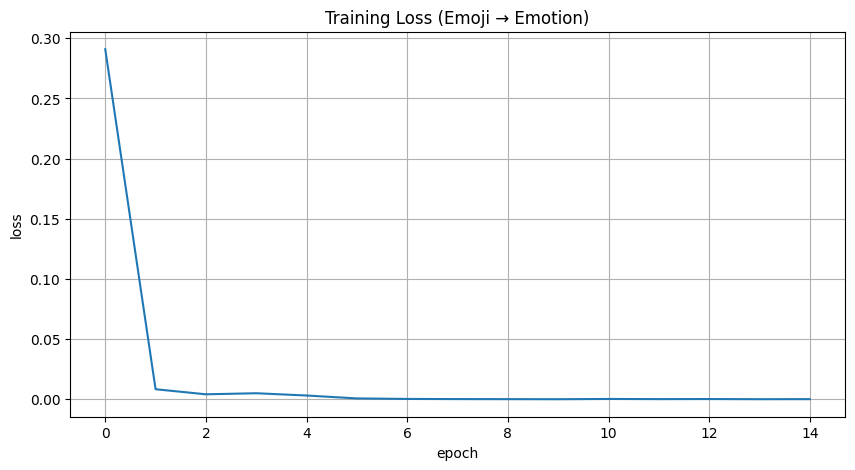


Тестирование:
ok :) -> счастлив
ok :D -> очень_счастлив
ok :( -> грустный
ok :):) -> счастлив счастлив
ok :):D -> счастлив очень_счастлив
ok ;):P -> подмигивает дразнится
ok :*:O -> целует удивлен
ok :'( -> плачет
ok :|:] -> нейтрален радостный
ok :):(:D -> счастлив грустный очень_счастлив
Accuracy: 10/10 (100%)

Сравнение результатов:
Вход (смайлики)      Ожидаемый результат            Предсказание        
:)                   счастлив                       счастлив            
:D                   очень_счастлив                 очень_счастлив      
:(                   грустный                       грустный            
:):)                 счастлив счастлив              счастлив счастлив   
:):D                 счастлив очень_счастлив        счастлив очень_счастлив
;):P                 подмигивает дразнится          подмигивает дразнится
:*:O                 целует удивлен                 целует удивлен      
:'(                  плачет                         плачет              


In [36]:
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"using device: {device}")

    model, dataset, losses = train_emoji_model(device)

    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Training Loss (Emoji → Emotion)')
    plt.grid(True)
    plt.show()

    test_emoji_model(model, dataset, device)